# TF - IDF


In [3]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/Users/dmk6603/Documents/ransom_victims/1-ransomware.live_data/data/victims.csv")

# Drop rows with no activity label
df_activity = df.dropna(subset=['activity'])
df_activity = df_activity[
    (df_activity['activity'].str.strip() != '') &
    (df_activity['activity'].str.lower().str.strip() != 'not found')
]

# Filter to groups with enough victims to be meaningful
group_counts = df_activity['group_name'].value_counts()
active_groups = group_counts[group_counts >= 15].index
df_activity = df_activity[df_activity['group_name'].isin(active_groups)]

# Build "documents": each group's victims' sectors concatenated
group_docs = (
    df_activity
    .groupby('group_name')['activity']
    .apply(lambda x: ' '.join(x.str.lower().str.strip()))
    .reset_index()
)
group_docs.columns = ['group_name', 'sector_doc']

# TF-IDF
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(group_docs['sector_doc'])
feature_names = vectorizer.get_feature_names_out()

# Convert to DataFrame for easy analysis
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    index=group_docs['group_name'],
    columns=feature_names
)

# Show top 5 distinctive sectors per group
for group in tfidf_df.index:
    top = tfidf_df.loc[group].nlargest(5)
    print(f"\n=== {group} ===")
    for sector, score in top.items():
        if score > 0:
            print(f"  {sector}: {score:.3f}")


=== 8base ===
  business: 0.586
  services: 0.557
  manufacturing: 0.401
  and: 0.179
  production: 0.158

=== BrainCipher ===
  services: 0.571
  business: 0.480
  manufacturing: 0.400
  technology: 0.329
  financial: 0.180

=== ElDorado ===
  business: 0.622
  services: 0.591
  technology: 0.334
  manufacturing: 0.226
  logistics: 0.146

=== J ===
  construction: 0.595
  technology: 0.431
  manufacturing: 0.374
  sector: 0.241
  public: 0.215

=== SilentRansomGroup ===
  services: 0.801
  business: 0.469
  financial: 0.359
  hospitality: 0.054
  tourism: 0.054

=== abyss ===
  services: 0.481
  business: 0.466
  technology: 0.320
  healthcare: 0.305
  production: 0.263

=== akira ===
  services: 0.514
  manufacturing: 0.512
  business: 0.367
  construction: 0.245
  and: 0.217

=== alphalocker ===
  business: 0.504
  services: 0.479
  technology: 0.384
  healthcare: 0.329
  manufacturing: 0.319

=== alphv ===
  business: 0.546
  services: 0.520
  facilities: 0.334
  healthcare: 0.282

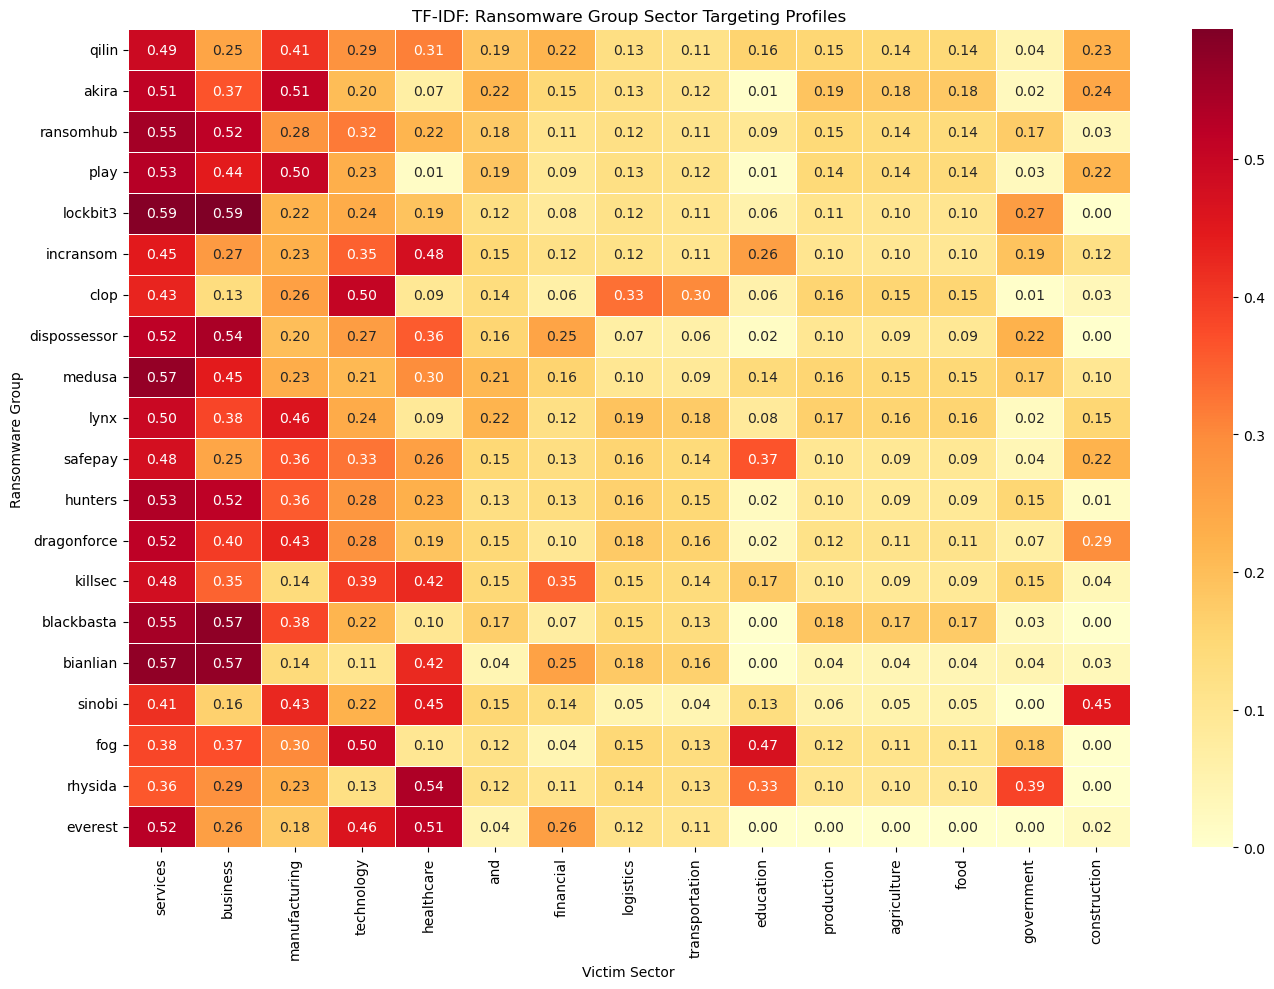

In [4]:
# Filter to top N groups and top M sectors for readability
top_groups = group_counts.head(20).index
top_sectors = tfidf_df.loc[top_groups].mean().nlargest(15).index

plt.figure(figsize=(14, 10))
sns.heatmap(
    tfidf_df.loc[top_groups, top_sectors],
    cmap='YlOrRd',
    annot=True,
    fmt='.2f',
    linewidths=0.5
)
plt.title('TF-IDF: Ransomware Group Sector Targeting Profiles')
plt.xlabel('Victim Sector')
plt.ylabel('Ransomware Group')
plt.tight_layout()
plt.savefig('tfidf_heatmap.png', dpi=150)
plt.show()

# Country

In [5]:
df_country = df.dropna(subset=['country'])
df_country = df_country[df_country['country'].str.strip() != '']
df_country = df_country[df_country['group_name'].isin(active_groups)]

country_docs = (
    df_country
    .groupby('group_name')['country']
    .apply(lambda x: ' '.join(x.str.upper().str.strip()))
    .reset_index()
)
country_docs.columns = ['group_name', 'country_doc']

vec_country = TfidfVectorizer()
tfidf_country = vec_country.fit_transform(country_docs['country_doc'])

tfidf_country_df = pd.DataFrame(
    tfidf_country.toarray(),
    index=country_docs['group_name'],
    columns=vec_country.get_feature_names_out()
)

# Description

In [6]:
df_desc = df.dropna(subset=['description'])
df_desc = df_desc[df_desc['description'].str.len() > 20]  # filter out short junk

desc_docs = (
    df_desc
    .groupby('group_name')['description']
    .apply(' '.join)
    .reset_index()
)

vec_desc = TfidfVectorizer(max_features=200, stop_words='english')
tfidf_desc = vec_desc.fit_transform(desc_docs['description'])

COUNTRY TF-IDF ANALYSIS
Total records with valid country: 15852
Groups included: 141
Unique countries: 184

=== 8base ===
  us: 0.539
  fr: 0.478
  it: 0.303
  au: 0.228
  de: 0.210

=== BrainCipher ===
  us: 0.473
  fr: 0.428
  mx: 0.424
  es: 0.261
  gh: 0.248

=== ElDorado ===
  us: 0.954
  ca: 0.135
  it: 0.135
  hr: 0.127
  aw: 0.111

=== J ===
  us: 0.381
  ar: 0.358
  ve: 0.351
  in: 0.296
  fr: 0.275

=== SilentRansomGroup ===
  us: 0.998
  ru: 0.037
  de: 0.036
  ca: 0.035

=== abyss ===
  us: 0.964
  gb: 0.136
  ca: 0.106
  ch: 0.102
  hk: 0.067

=== akira ===
  us: 0.975
  ca: 0.122
  de: 0.099
  it: 0.060
  ch: 0.056

=== alphalocker ===
  us: 0.758
  th: 0.294
  is: 0.289
  gb: 0.255
  br: 0.209

=== alphv ===
  us: 0.736
  ca: 0.287
  au: 0.271
  gb: 0.188
  ao: 0.179

=== anubis ===
  us: 0.891
  au: 0.304
  ca: 0.163
  bg: 0.129
  nz: 0.108

=== apos ===
  br: 0.825
  us: 0.272
  ar: 0.255
  in: 0.211
  es: 0.200

=== apt73 ===
  gb: 0.548
  us: 0.381
  in: 0.346
  id: 

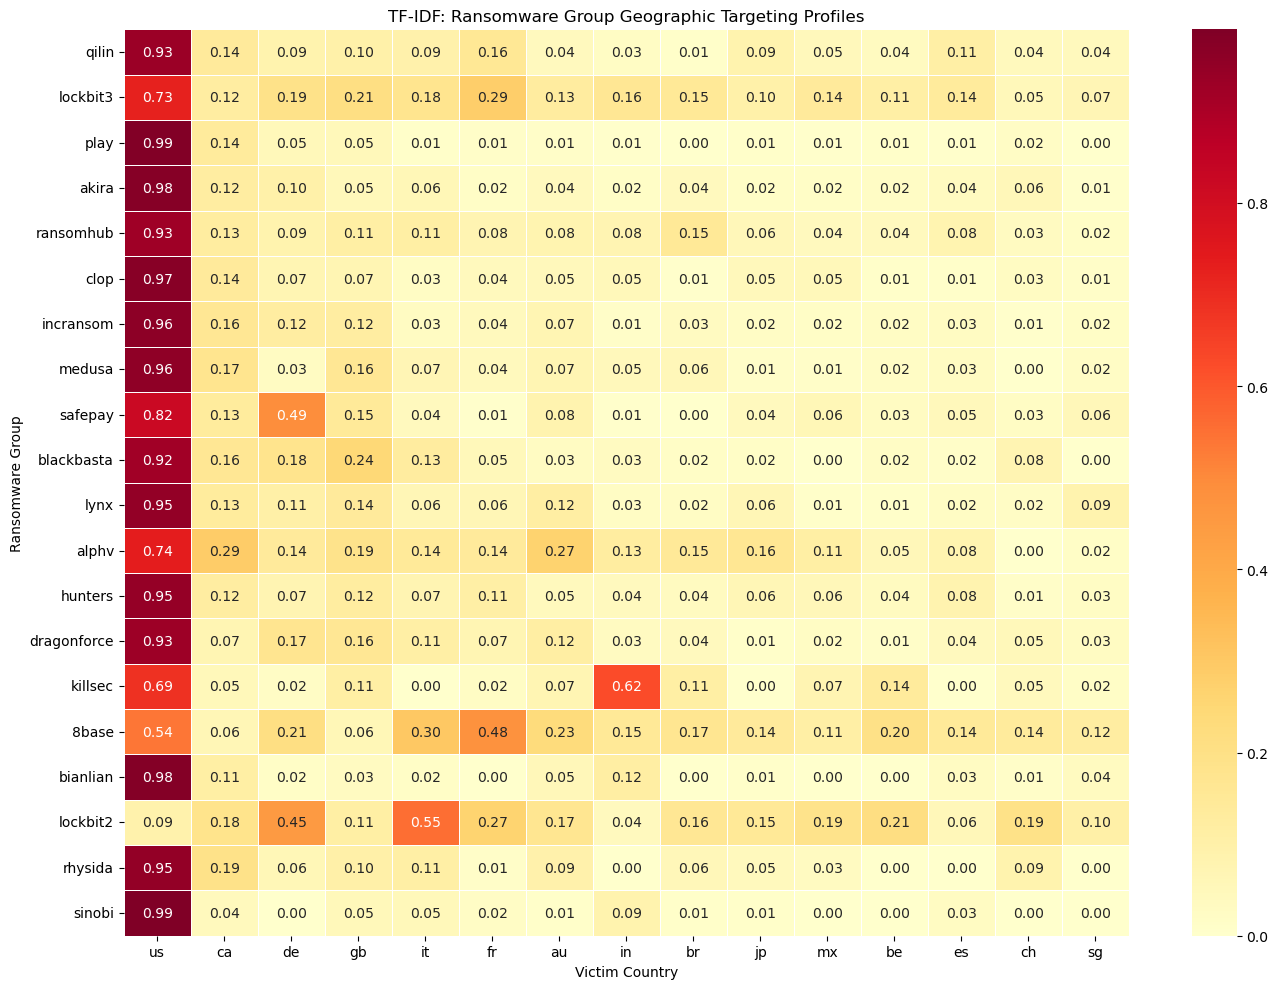


Saved: tfidf_country_scores.csv

DESCRIPTION TF-IDF ANALYSIS
Total records with valid description: 16469
Groups included: 124

=== 8base ===
  com: 0.504
  https: 0.353
  www: 0.339
  https www: 0.257
  products: 0.149
  quality: 0.142
  business: 0.134
  service: 0.129
  years: 0.127
  br: 0.091

=== BrainCipher ===
  generated: 0.449
  ai generated: 0.368
  ai: 0.310
  known: 0.182
  including: 0.181
  quality: 0.147
  specializing: 0.141
  range: 0.136
  property: 0.135
  firm: 0.129

=== ElDorado ===
  revenue: 0.343
  million: 0.280
  generated: 0.219
  solutions: 0.217
  ai generated: 0.184
  specializing: 0.173
  focus: 0.162
  company specializing: 0.158
  ai: 0.155
  employees: 0.152

=== J ===
  ai generated: 0.511
  generated: 0.493
  ai: 0.454
  specializing: 0.145
  solutions: 0.132
  construction: 0.129
  range: 0.126
  based: 0.121
  company specializing: 0.109
  uk: 0.109

=== SilentRansomGroup ===
  law: 0.403
  firm: 0.372
  law firm: 0.348
  founded: 0.316
  insuran

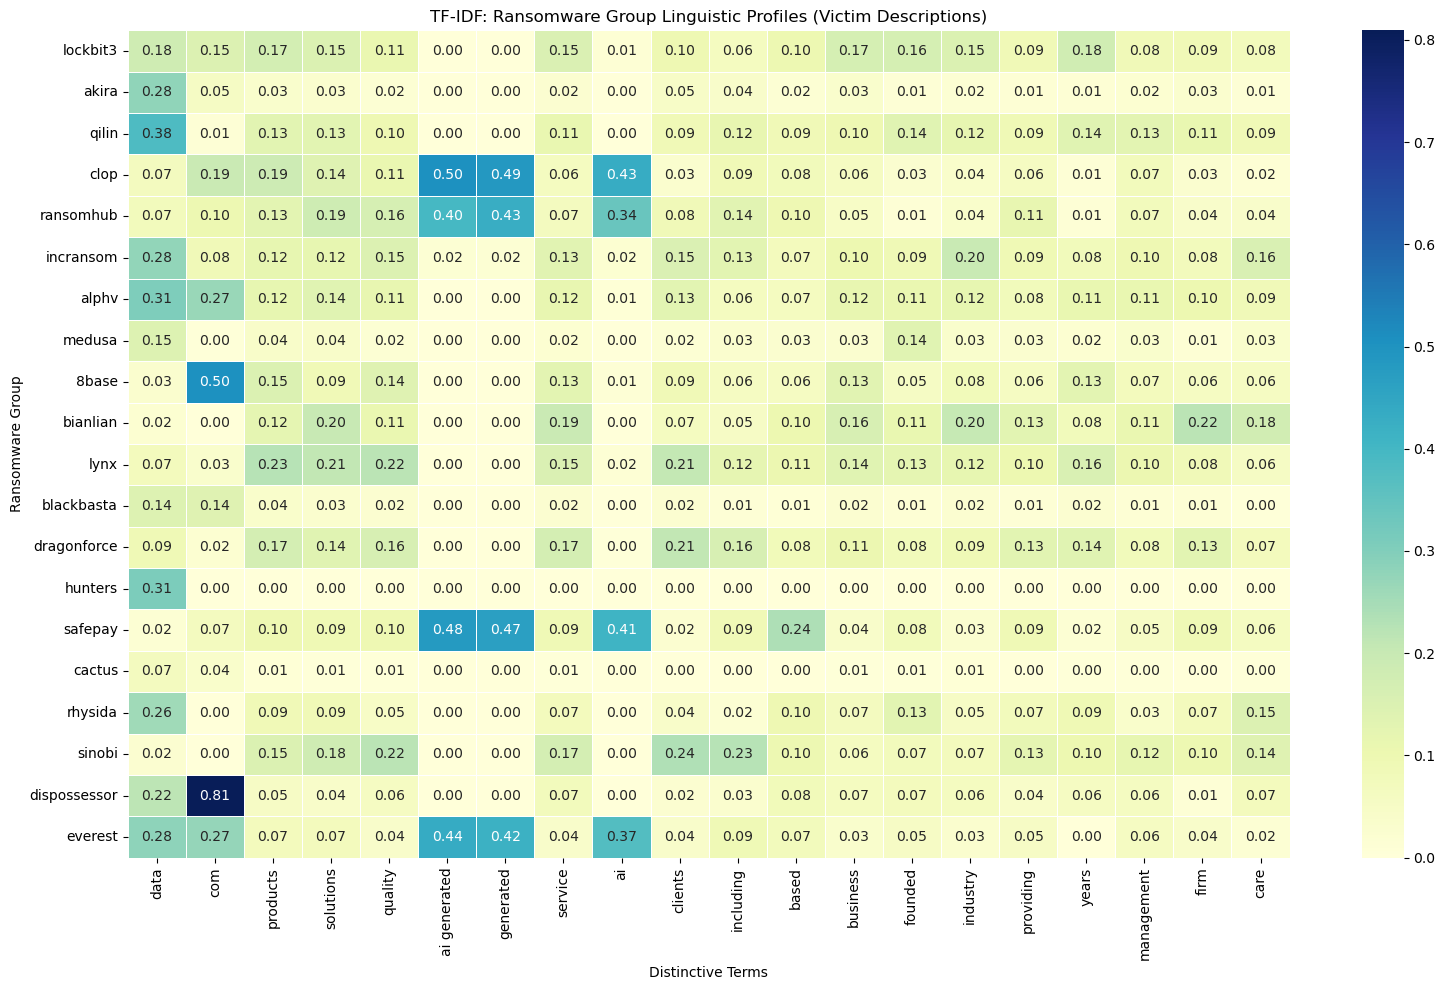


Saved: tfidf_description_scores.csv

GROUP SIMILARITY (by country targeting)


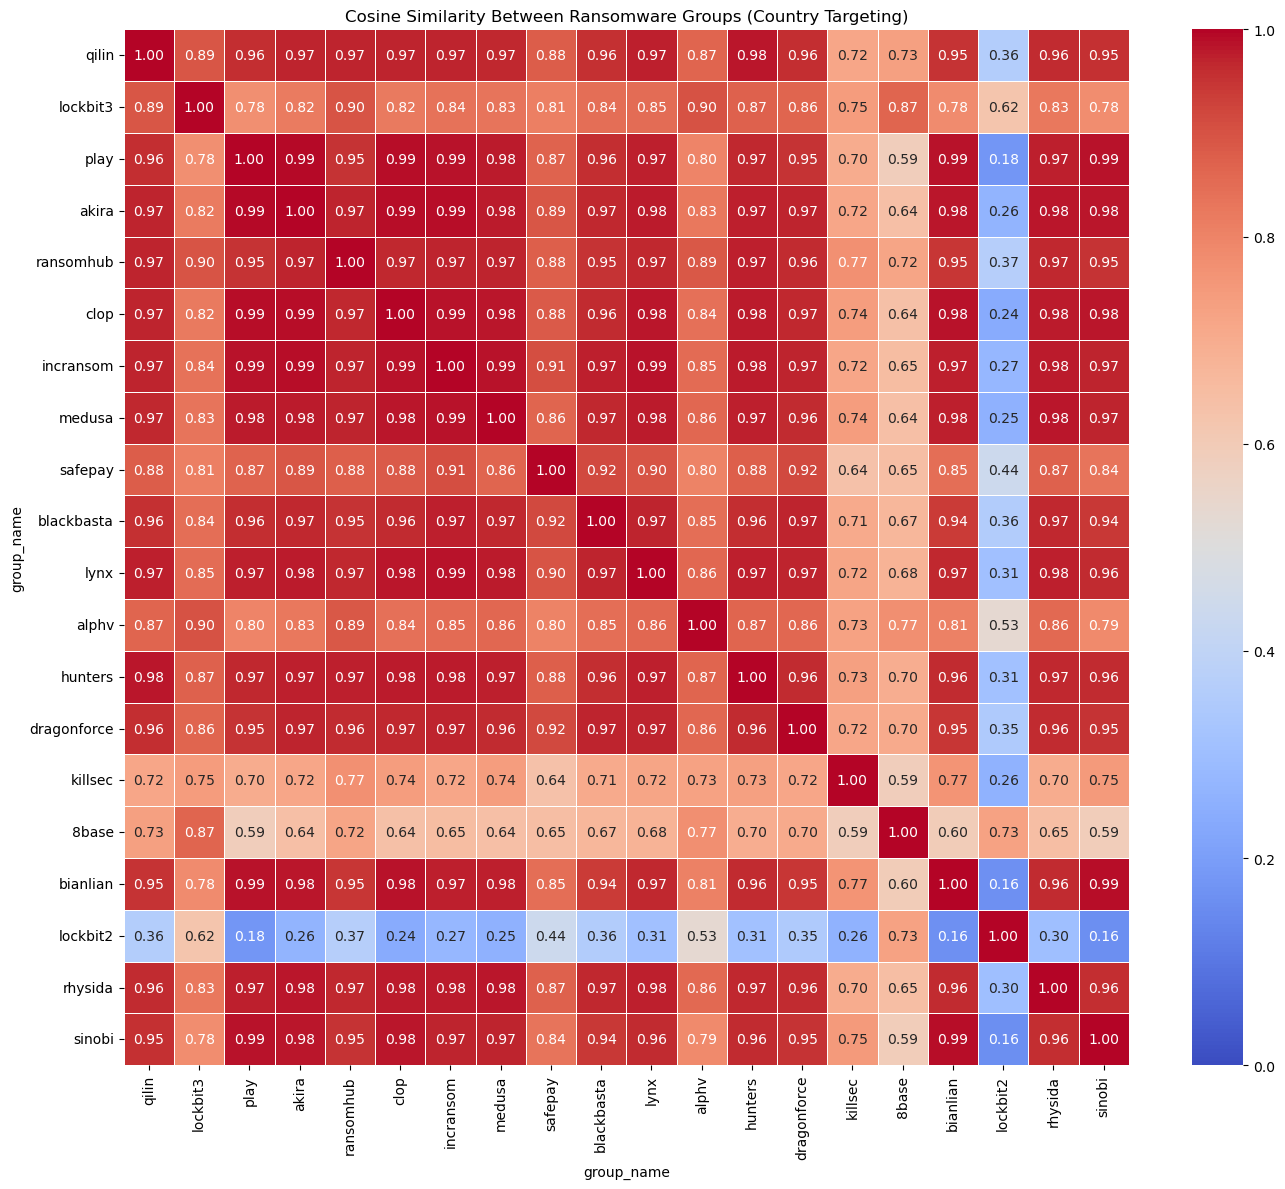


GROUP SIMILARITY (by description language)


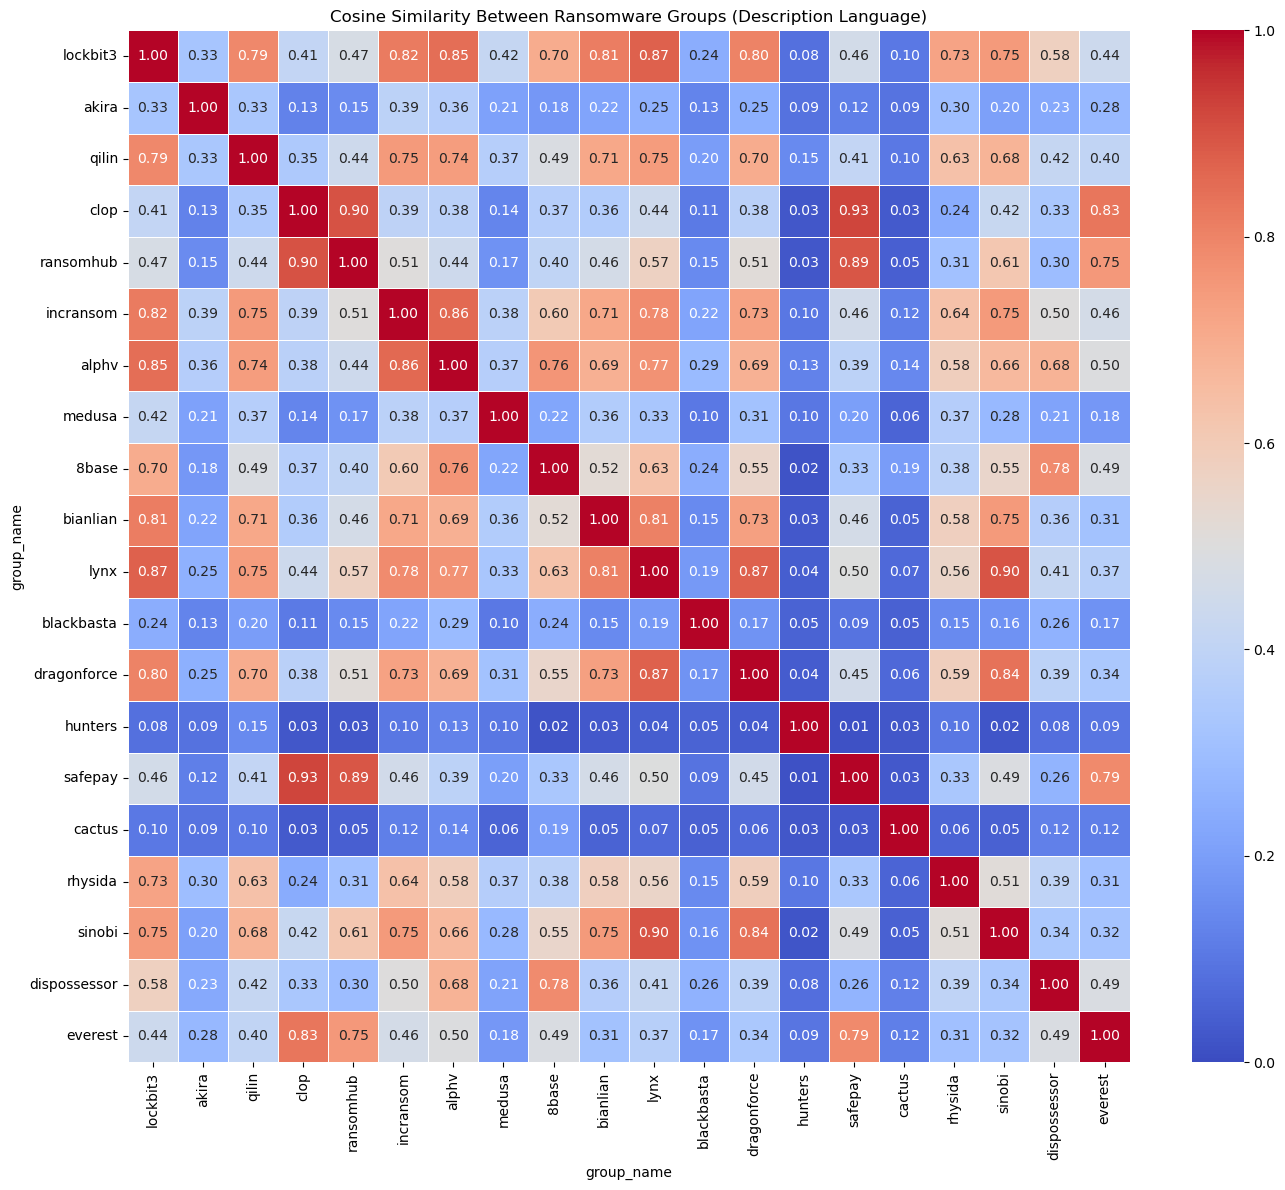


Saved: group_similarity_country.csv, group_similarity_description.csv


In [8]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("/Users/dmk6603/Documents/ransom_victims/1-ransomware.live_data/data/victims.csv")

# ============================================================
# COMMON: Filter to groups with enough victims
# ============================================================
group_counts = df['group_name'].value_counts()
active_groups = group_counts[group_counts >= 15].index

# ============================================================
# 1. COUNTRY TF-IDF ANALYSIS
# ============================================================
print("=" * 60)
print("COUNTRY TF-IDF ANALYSIS")
print("=" * 60)

df_country = df.dropna(subset=['country'])
df_country = df_country[
    (df_country['country'].str.strip() != '') &
    (df_country['country'].str.lower().str.strip() != 'not found')
]
df_country = df_country[df_country['group_name'].isin(active_groups)]

print(f"Total records with valid country: {len(df_country)}")
print(f"Groups included: {df_country['group_name'].nunique()}")
print(f"Unique countries: {df_country['country'].nunique()}")

# Build documents: each group's victim countries concatenated
country_docs = (
    df_country
    .groupby('group_name')['country']
    .apply(lambda x: ' '.join(x.str.upper().str.strip()))
    .reset_index()
)
country_docs.columns = ['group_name', 'country_doc']

# TF-IDF
vec_country = TfidfVectorizer()
tfidf_country_matrix = vec_country.fit_transform(country_docs['country_doc'])
country_features = vec_country.get_feature_names_out()

tfidf_country_df = pd.DataFrame(
    tfidf_country_matrix.toarray(),
    index=country_docs['group_name'],
    columns=country_features
)

# Print top 5 distinctive countries per group
for group in tfidf_country_df.index:
    top = tfidf_country_df.loc[group].nlargest(5)
    print(f"\n=== {group} ===")
    for country, score in top.items():
        if score > 0:
            print(f"  {country}: {score:.3f}")

# Heatmap: top 20 groups × top 15 countries
top_country_groups = (
    df_country['group_name']
    .value_counts()
    .head(20)
    .index
    .intersection(tfidf_country_df.index)
)
top_countries = tfidf_country_df.loc[top_country_groups].mean().nlargest(15).index

plt.figure(figsize=(14, 10))
sns.heatmap(
    tfidf_country_df.loc[top_country_groups, top_countries],
    cmap='YlOrRd',
    annot=True,
    fmt='.2f',
    linewidths=0.5
)
plt.title('TF-IDF: Ransomware Group Geographic Targeting Profiles')
plt.xlabel('Victim Country')
plt.ylabel('Ransomware Group')
plt.tight_layout()
plt.savefig('tfidf_country_heatmap.png', dpi=150)
plt.show()

# Export country TF-IDF scores to CSV
tfidf_country_df.to_csv('tfidf_country_scores.csv')
print("\nSaved: tfidf_country_scores.csv")


# ============================================================
# 2. DESCRIPTION TF-IDF ANALYSIS
# ============================================================
print("\n" + "=" * 60)
print("DESCRIPTION TF-IDF ANALYSIS")
print("=" * 60)

df_desc = df.dropna(subset=['description'])
df_desc = df_desc[
    (df_desc['description'].str.strip() != '') &
    (df_desc['description'].str.lower().str.strip() != 'not found') &
    (df_desc['description'].str.len() > 20)  # filter out very short junk
]
df_desc = df_desc[df_desc['group_name'].isin(active_groups)]

print(f"Total records with valid description: {len(df_desc)}")
print(f"Groups included: {df_desc['group_name'].nunique()}")

# Build documents: each group's descriptions concatenated
desc_docs = (
    df_desc
    .groupby('group_name')['description']
    .apply(lambda x: ' '.join(x.str.lower().str.strip()))
    .reset_index()
)
desc_docs.columns = ['group_name', 'desc_doc']

# TF-IDF with more tuning for free text
vec_desc = TfidfVectorizer(
    max_features=300,       # limit to top 300 terms
    stop_words='english',   # remove common English words
    min_df=2,               # term must appear in at least 2 groups
    max_df=0.85,            # ignore terms in >85% of groups
    ngram_range=(1, 2)      # include bigrams (e.g., "law firm", "data breach")
)
tfidf_desc_matrix = vec_desc.fit_transform(desc_docs['desc_doc'])
desc_features = vec_desc.get_feature_names_out()

tfidf_desc_df = pd.DataFrame(
    tfidf_desc_matrix.toarray(),
    index=desc_docs['group_name'],
    columns=desc_features
)

# Print top 10 distinctive terms per group
for group in tfidf_desc_df.index:
    top = tfidf_desc_df.loc[group].nlargest(10)
    print(f"\n=== {group} ===")
    for term, score in top.items():
        if score > 0:
            print(f"  {term}: {score:.3f}")

# Heatmap: top 20 groups × top 20 terms
top_desc_groups = (
    df_desc['group_name']
    .value_counts()
    .head(20)
    .index
    .intersection(tfidf_desc_df.index)
)
top_terms = tfidf_desc_df.loc[top_desc_groups].mean().nlargest(20).index

plt.figure(figsize=(16, 10))
sns.heatmap(
    tfidf_desc_df.loc[top_desc_groups, top_terms],
    cmap='YlGnBu',
    annot=True,
    fmt='.2f',
    linewidths=0.5
)
plt.title('TF-IDF: Ransomware Group Linguistic Profiles (Victim Descriptions)')
plt.xlabel('Distinctive Terms')
plt.ylabel('Ransomware Group')
plt.tight_layout()
plt.savefig('tfidf_description_heatmap.png', dpi=150)
plt.show()

# Export description TF-IDF scores to CSV
tfidf_desc_df.to_csv('tfidf_description_scores.csv')
print("\nSaved: tfidf_description_scores.csv")


# ============================================================
# 3. BONUS: Cosine similarity between groups
# ============================================================
from sklearn.metrics.pairwise import cosine_similarity

# Country-based similarity
print("\n" + "=" * 60)
print("GROUP SIMILARITY (by country targeting)")
print("=" * 60)

country_sim = cosine_similarity(tfidf_country_matrix)
country_sim_df = pd.DataFrame(
    country_sim,
    index=country_docs['group_name'],
    columns=country_docs['group_name']
)

plt.figure(figsize=(14, 12))
sns.heatmap(
    country_sim_df.loc[top_country_groups, top_country_groups],
    cmap='coolwarm',
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    vmin=0, vmax=1
)
plt.title('Cosine Similarity Between Ransomware Groups (Country Targeting)')
plt.tight_layout()
plt.savefig('group_similarity_country.png', dpi=150)
plt.show()

# Description-based similarity
print("\n" + "=" * 60)
print("GROUP SIMILARITY (by description language)")
print("=" * 60)

desc_sim = cosine_similarity(tfidf_desc_matrix)
desc_sim_df = pd.DataFrame(
    desc_sim,
    index=desc_docs['group_name'],
    columns=desc_docs['group_name']
)

plt.figure(figsize=(14, 12))
sns.heatmap(
    desc_sim_df.loc[top_desc_groups, top_desc_groups],
    cmap='coolwarm',
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    vmin=0, vmax=1
)
plt.title('Cosine Similarity Between Ransomware Groups (Description Language)')
plt.tight_layout()
plt.savefig('group_similarity_description.png', dpi=150)
plt.show()

country_sim_df.to_csv('group_similarity_country.csv')
desc_sim_df.to_csv('group_similarity_description.csv')
print("\nSaved: group_similarity_country.csv, group_similarity_description.csv")